In [45]:
!pip install -q transformers datasets accelerate

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional
import warnings

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


# 1) Similarity Metrics

Before we can train or evaluate embeddings, we need a way to measure how
"close" two vectors are. The choice of metric has deep consequences for
the geometry of the learned embedding space.

We implement three fundamental metrics:

| Metric | Formula | Range | Key Property |
|---|---|---|---|
| **Cosine Similarity** | `a·b / (‖a‖·‖b‖)` | [-1, 1] | Magnitude-invariant |
| **Dot Product** | `a·b = Σ aᵢbᵢ` | (-∞, +∞) | Encodes both direction and magnitude |
| **L2 (Euclidean) Distance** | `‖a-b‖₂` | [0, +∞) | True metric (triangle inequality) |

### Sample Input / Output

```
a = [1.0, 0.0, 1.0]    b = [0.0, 1.0, 1.0]

cosine_similarity(a, b) → 0.5
dot_product(a, b)       → 1.0
l2_distance(a, b)       → 1.414
```

- When vectors are L2-normalized, they are scaled so their total length is exactly 1, effectively placing them on the surface of a unit sphere.
- Because their magnitudes are fixed, the math simplifies dramatically: the Dot Product becomes exactly equal to Cosine Similarity, and the Squared L2 (Euclidean) Distance becomes a direct inverse of it (2 - 2 * Cosine).
- This "monotonic relationship" means all three metrics will rank vector similarities in the exact same order, allowing developers to simply use the fastest computation (usually Dot Product) without agonizing over which metric to choose.

```
‖a-b‖² = 2 - 2·cos(a,b)   and   dot(a,b) = cos(a,b)
```

In [47]:
def cosine_similarity_matrix(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    Compute pairwise cosine similarity between two batches of vectors.

    Cosine similarity measures the angle between two vectors, ignoring
    magnitude. This makes it robust to differences in sentence length
    or encoder scaling, which is why it is the default metric for
    most text embedding benchmarks (MTEB, STS).

    Args:
        a: (batch_a, embed_dim) — first set of embeddings
        b: (batch_b, embed_dim) — second set of embeddings

    Returns:
        (batch_a, batch_b) — pairwise cosine similarities
    """
    # L2-normalize each vector so dot product equals cosine similarity.
    # eps prevents division by zero for degenerate zero-vectors.

    # (batch, embed_dim)
    a_norm = F.normalize(a, p=2, dim=-1)
    b_norm = F.normalize(b, p=2, dim=-1)

    # Matrix multiply: each row of a_norm against each row of b_norm.
    # (batch_a, batch_b)
    return a_norm @ b_norm.T


def dot_product_matrix(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    Compute pairwise dot product between two batches of vectors.

    Unlike cosine similarity, dot product is sensitive to vector magnitude.
    This allows the model to encode "importance" or "confidence" in the
    vector norm

    Args:
        a: (batch_a, embed_dim)
        b: (batch_b, embed_dim)

    Returns:
        (batch_a, batch_b) — pairwise dot products
    """
    # (batch_a, embed_dim) @ (embed_dim, batch_b) -> (batch_a, batch_b)
    return a @ b.T


def l2_distance_matrix(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    Compute pairwise L2 (Euclidean) distances between two batches.

    L2 is a proper metric satisfying the triangle inequality, making it
    compatible with spatial indexing structures (KD-trees, ball trees).
    We use the expanded form to avoid materializing the full difference
    tensor, which would be O(batch_a * batch_b * embed_dim) in memory.

    Identity: ‖a-b‖² = ‖a‖² + ‖b‖² - 2·a·b

    Args:
        a: (batch_a, embed_dim)
        b: (batch_b, embed_dim)

    Returns:
        (batch_a, batch_b) — pairwise L2 distances
    """
    # Squared norms for each vector
    # (batch_a, embed_dim) -> (batch_a, 1)
    a_sq = (a * a).sum(dim=-1, keepdim=True)
    # (batch_b, embed_dim) -> (1, batch_b)
    b_sq = (b * b).sum(dim=-1, keepdim=True).T

    # Expanded form of squared Euclidean distance.
    # (batch_a, 1) + (1, batch_b) - 2*(batch_a, batch_b) -> (batch_a, batch_b)
    sq_dist = a_sq + b_sq - 2.0 * (a @ b.T)

    # Clamp to avoid tiny negative values from floating point errors.
    return torch.sqrt(torch.clamp(sq_dist, min=0.0))

In [48]:
# === Verifying the Metric Equivalence ===
torch.manual_seed(42)

# Create random embeddings simulating a small batch.
# 5 vectors of dimension 64
raw_vecs = torch.randn(5, 64)

# L2-normalize to place all vectors on the unit hypersphere.
# (5, 64) -> (5, 64) with ‖v‖=1 for each row
unit_vecs = F.normalize(raw_vecs, p=2, dim=-1)

cos_sim = cosine_similarity_matrix(unit_vecs, unit_vecs)
dot_sim = dot_product_matrix(unit_vecs, unit_vecs)
l2_dist = l2_distance_matrix(unit_vecs, unit_vecs)

# Verify: for normalized vectors, cosine == dot product
print("Max |cos - dot| :", (cos_sim - dot_sim).abs().max().item())

# Verify: ‖a-b‖² = 2 - 2*cos(a,b)
reconstructed_l2_sq = 2.0 - 2.0 * cos_sim
actual_l2_sq = l2_dist ** 2
print("Max |L2² - (2-2cos)| :", (actual_l2_sq - reconstructed_l2_sq).abs().max().item())

# Verify ranking equivalence: highest cosine <=> lowest L2.
cos_rank = cos_sim[0, 1:].argsort(descending=True)
l2_rank = l2_dist[0, 1:].argsort(descending=False)
print(f"Cosine ranking: {cos_rank.tolist()}")
print(f"L2 ranking:     {l2_rank.tolist()}")

Max |cos - dot| : 1.1920928955078125e-07
Max |L2² - (2-2cos)| : 4.76837158203125e-07
Cosine ranking: [0, 1, 3, 2]
L2 ranking:     [0, 1, 3, 2]


# 2) Bi-Encoder Architecture

A **bi-encoder** independently encodes two pieces of text into fixed-size
vectors, then compares them with a cheap similarity function (e.g., cosine).
This decoupled design enables:

- **Pre-computation**: Encode a corpus once, store the vectors.
- **Sublinear retrieval**: Use ANN indices (FAISS, ScaNN) for O(log n) search.
- **Scalability**: Comparing 1M documents costs 1M dot products, not 1M transformer forward passes.

![](https://user-images.githubusercontent.com/36184621/97063333-0ff99200-15da-11eb-99d6-5143eaba790b.png)

Both branches typically share weights (Siamese architecture), though
asymmetric designs exist for query-document retrieval (DPR).


## 2.1 Pooling Strategies

The transformer outputs a (seq_len, model_dim) matrix. We need a single
(embed_dim,) vector. Common strategies:

| Strategy | Method | Pros | Cons |
|---|---|---|---|
| **[CLS] token** | Take hidden state at position 0 | Simple, BERT default | CLS not trained for sentence meaning in base models |
| **Mean pooling** | Average all token hidden states | Empirically strongest for SBERT | Diluted by padding tokens |
| **Weighted mean** | Attention-weighted average | Focuses on salient tokens | Extra parameters |
| **Max pooling** | Element-wise max over sequence | Captures strongest feature activations | Loses positional info |

In [49]:
class PoolingLayer(nn.Module):
    """
    Converts variable-length transformer outputs into a single fixed-size vector.

    mean pooling is the default because it
    consistently outperforms [CLS] on STS benchmarks (Reimers & Gurevych, 2019).
    The attention_mask is critical — without it, mean pooling averages over
    PAD tokens, which are meaningless and degrade the representation.
    """

    def __init__(self, strategy: str = "mean", model_dim: int = 768):
        super().__init__()
        assert strategy in ("cls", "mean", "max", "weighted_mean")
        self.strategy = strategy

        # Weighted mean: learn a scalar importance weight per hidden dimension.
        # This lets the model attend more to certain feature channels.
        if strategy == "weighted_mean":
            # (model_dim,) — one learnable weight per feature dimension
            self.feature_weights = nn.Parameter(torch.ones(model_dim))

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            hidden_states: (batch_num, seq_len, model_dim) — transformer output
            attention_mask: (batch_num, seq_len) — 1 for real tokens, 0 for PAD

        Returns:
            (batch_num, model_dim) — pooled sentence embedding
        """
        if self.strategy == "cls":
            # Take the hidden state at position 0 (the [CLS] token).
            # (batch_num, seq_len, model_dim) -> (batch_num, model_dim)
            return hidden_states[:, 0, :]

        if self.strategy == "mean":
            # Expand mask to broadcast over model_dim.
            # (batch_num, seq_len) -> (batch_num, seq_len, 1)
            mask_expanded = attention_mask.unsqueeze(-1).float()

            # Zero out PAD positions, then sum over sequence.
            # Input: (batch_num, seq_len, model_dim) * (batch_num, seq_len, 1)
            # Output: (batch_num, seq_len, model_dim) -> sum -> (batch_num, model_dim)
            summed = (hidden_states * mask_expanded).sum(dim=1)

            # Count of real tokens per example (avoid division by zero).
            # (batch_num, seq_len, 1) -> (batch_num, 1)
            counts = mask_expanded.sum(dim=1).clamp(min=1e-9)

            # (batch_num, model_dim) / (batch_num, 1) -> (batch_num, model_dim)
            return summed / counts

        if self.strategy == "max":
            # Replace PAD positions with -inf so they never win the max.
            # (batch_num, seq_len) -> (batch_num, seq_len, 1)
            mask_expanded = attention_mask.unsqueeze(-1).float()
            hidden_states = hidden_states.masked_fill(mask_expanded == 0, -1e9)

            # Element-wise max over the sequence dimension.
            # (batch_num, seq_len, model_dim) -> (batch_num, model_dim)
            return hidden_states.max(dim=1).values

        if self.strategy == "weighted_mean":
            # Softmax over feature dimension gives learned importance weights.
            # (model_dim,) -> (model_dim,)
            weights = F.softmax(self.feature_weights, dim=0)

            # Multiply hidden states by learned feature weights.
            # Input (batch_num, seq_len, model_dim) * (model_dim,)
            # Output (batch_num, seq_len, model_dim)
            weighted = hidden_states * weights.unsqueeze(0).unsqueeze(0)

            # Then standard mean pooling on the weighted representation.
            mask_expanded = attention_mask.unsqueeze(-1).float()
            summed = (weighted * mask_expanded).sum(dim=1)
            counts = mask_expanded.sum(dim=1).clamp(min=1e-9)
            return summed / counts

## 2.2 The Bi-Encoder Model

- We wrap a frozen/fine-tunable transformer backbone with our pooling
layer and an optional linear projection head.
- The projection head is
common when the desired embedding dimension differs from the model's
hidden size, or when training with contrastive loss
- (Chen et al., SimCLR 2020
showed that a projection head during training improves representation quality).

In [50]:
class BiEncoder(nn.Module):
    """
    Bi-Encoder for text embedding.

    Architecture: Transformer Backbone -> Pooling -> (Optional) Projection -> L2-Norm

    Design decisions:
      - Shared weights (Siamese): Reduces parameters by 2x. Asymmetric
        encoders (like DPR) can outperform on retrieval but break symmetry
        needed for STS tasks.
      - L2 normalization: Projects embeddings onto the unit hypersphere,
        making cosine sim == dot product. This simplifies ANN indexing
        and stabilizes contrastive loss gradients.
      - Projection head: Following SimCLR (Chen et al., 2020), we include
        an optional MLP projection used *during training only*. At inference,
        we can discard it and use the pooled representation directly.
    """

    def __init__(
        self,
        model_name: str = "bert-base-uncased",
        pooling_strategy: str = "mean",
        embed_dim: Optional[int] = None,
        normalize: bool = True,
    ):
        super().__init__()

        # Load the pretrained transformer backbone from HuggingFace.
        self.backbone = AutoModel.from_pretrained(model_name)
        self.model_dim = self.backbone.config.hidden_size
        self.normalize = normalize

        # Custom pooling layer
        self.pool = PoolingLayer(strategy=pooling_strategy, model_dim=self.model_dim)

        # Optional projection to a different embedding dimension.
        # If embed_dim is None, we use the backbone's hidden size directly.
        self.projection = None
        if embed_dim is not None and embed_dim != self.model_dim:
            # (model_dim,) -> (embed_dim,)
            self.projection = nn.Sequential(
                nn.Linear(self.model_dim, self.model_dim),
                nn.GELU(),
                nn.Linear(self.model_dim, embed_dim),
            )

        self.effective_dim = embed_dim if embed_dim is not None else self.model_dim

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Encode a batch of tokenized texts into fixed-size embeddings.

        Args:
            input_ids:      (batch_num, seq_len) — token IDs
            attention_mask: (batch_num, seq_len) — 1 for real, 0 for PAD

        Returns:
            (batch_num, embed_dim) — L2-normalized (if enabled) embeddings
        """
        # Forward through the transformer backbone.
        # (batch_num, seq_len) -> (batch_num, seq_len, model_dim)
        outputs = self.backbone(
            input_ids=input_ids, attention_mask=attention_mask
        )
        hidden_states = outputs.last_hidden_state

        # Pool sequence of token embeddings into a single sentence vector.
        # (batch_num, seq_len, model_dim) -> (batch_num, model_dim)
        pooled = self.pool(hidden_states, attention_mask)

        # Optional projection to target embedding dimension.
        if self.projection is not None:
            # (batch_num, model_dim) -> (batch_num, embed_dim)
            pooled = self.projection(pooled)

        # L2 normalization places embeddings on the unit hypersphere.
        if self.normalize:
            # (batch_num, embed_dim) -> (batch_num, embed_dim) with ‖v‖=1
            pooled = F.normalize(pooled, p=2, dim=-1)

        return pooled

    @torch.no_grad()
    def encode(
        self, texts: list[str], tokenizer, max_length: int = 128, batch_size: int = 32
    ) -> torch.Tensor:
        """
        Convenience method: raw strings -> embeddings.

        Handles tokenization and batching for inference.
        """
        self.eval()
        all_embeddings = []

        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i : i + batch_size]
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            ).to(DEVICE)

            embeddings = self.forward(
                input_ids=encoded["input_ids"],
                attention_mask=encoded["attention_mask"],
            )
            all_embeddings.append(embeddings.cpu())

        # (total_num_texts, embed_dim)
        return torch.cat(all_embeddings, dim=0)

In [51]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bi_encoder = BiEncoder(
    model_name="bert-base-uncased",
    pooling_strategy="mean",
    embed_dim=None,
    normalize=True,
).to(DEVICE)

# Test sentences: first two are semantically similar, third is different.
test_sentences = [
    "The cat sits on the mat.",
    "A kitten is resting on a rug.",
    "Stock markets rallied on strong earnings reports.",
]

# (3, 768)
embeddings = bi_encoder.encode(test_sentences, tokenizer)
print(f"Embedding shape: {embeddings.shape}")
print(f"Norms (should be ~1.0): {embeddings.norm(dim=-1).tolist()}")

# Pairwise cosine similarity.
sim_matrix = cosine_similarity_matrix(embeddings, embeddings)
print(f"\nCosine similarity matrix:")
for i, s in enumerate(test_sentences):
    print(f"  [{i}] {s}")
print(sim_matrix.numpy().round(3))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: torch.Size([3, 768])
Norms (should be ~1.0): [0.9999998807907104, 1.0, 1.0]

Cosine similarity matrix:
  [0] The cat sits on the mat.
  [1] A kitten is resting on a rug.
  [2] Stock markets rallied on strong earnings reports.
[[1.    0.821 0.532]
 [0.821 1.    0.542]
 [0.532 0.542 1.   ]]


# 3) Cross-Encoder Architecture & Comparison

A **cross-encoder** processes both texts jointly through the same transformer
using cross-attention between all token pairs. This is fundamentally more
expressive than a bi-encoder:

![](https://weaviate.io/assets/images/cross-encoder-61b340b8d1f6359bb7650da2c59be11c.png)

```
Bi-Encoder:    encode(A), encode(B) → sim(emb_A, emb_B)
Cross-Encoder: encode([A; SEP; B])  → score(A, B)
```

**Key Architectural Difference**
- In a bi-encoder, self-attention within text A cannot attend to tokens in
text B (independent encoding).
- In a cross-encoder, every token in A
attends to every token in B and vice versa, enabling rich token-level
interaction modeling.

**Why this matters — an example**

```
A: "Apple released a new product"
B: "The fruit was fresh from the orchard"

Bi-encoder:    "Apple" is encoded without seeing B.
               → Ambiguous between company and fruit.
Cross-encoder: "Apple" attends to "fruit" and "orchard".
               → Disambiguated as fruit. Correctly scores low relevance.
```

**Tradeoffs**

| Property | Bi-Encoder | Cross-Encoder |
|---|---|---|
| Accuracy | Good | Better (typically +2-5% on retrieval benchmarks) |
| Encoding speed | O(N) total, then O(1) per comparison | O(N×M) for N queries × M documents |
| Pre-computation | Yes (encode corpus once) | No (must process each pair) |
| ANN indexing | Yes | No |
| Use case | First-stage retrieval | Re-ranking top-k results |

**Retrieve-and-Rerank Pipeline**

The standard production pattern combines both:

```
1. Bi-encoder retrieves top-100 candidates from millions (fast, approximate)
2. Cross-encoder re-ranks top-100 to select top-10 (slow, accurate)
```

In [52]:
class CrossEncoder(nn.Module):
    """
    Cross-Encoder for text pair scoring.

    Unlike the bi-encoder, this processes both texts jointly.
    The transformer sees: [CLS] text_A [SEP] text_B [SEP]
    and cross-attention enables full token-level interaction.

    We take the [CLS] output and project it to a scalar relevance score.
    For training, we use binary cross-entropy (relevant/not relevant)
    or regression loss (for STS-style continuous similarity).

    Design choice: We use a 2-layer MLP head instead of a single linear
    layer. The extra non-linearity helps when the relationship between
    [CLS] representation and relevance is non-trivial.

    Reference: Nogueira & Cho, arXiv 2019
    """

    def __init__(self, model_name: str = "bert-base-uncased"):
        super().__init__()

        # The same transformer backbone, but used very differently.
        self.backbone = AutoModel.from_pretrained(model_name)
        model_dim = self.backbone.config.hidden_size

        # Classification head: [CLS] representation -> scalar score.
        # (model_dim,) -> (model_dim,) -> (1,)
        self.classifier = nn.Sequential(
            nn.Linear(model_dim, model_dim),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(model_dim, 1),
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        token_type_ids: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """
        Score a batch of text pairs.

        Args:
            input_ids:      (batch_num, seq_len) — [CLS] A [SEP] B [SEP]
            attention_mask: (batch_num, seq_len)
            token_type_ids: (batch_num, seq_len) — 0 for A tokens, 1 for B tokens

        Returns:
            (batch_num,) — relevance scores
        """
        # Joint encoding with full cross-attention.
        # (batch_num, seq_len) -> (batch_num, seq_len, model_dim)
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        # Extract [CLS] representation (position 0).
        # (batch_num, seq_len, model_dim) -> (batch_num, model_dim)
        cls_output = outputs.last_hidden_state[:, 0, :]

        # Project to scalar score.
        # (batch_num, model_dim) -> (batch_num, 1) -> (batch_num,)
        score = self.classifier(cls_output).squeeze(-1)

        return score

    @torch.no_grad()
    def predict(
        self,
        text_pairs: list[tuple[str, str]],
        tokenizer,
        max_length: int = 256,
    ) -> torch.Tensor:
        """
        Convenience method: score raw text pairs.

        Tokenizes with text pair encoding (segment IDs) and returns scores.
        """
        self.eval()

        texts_a = [p[0] for p in text_pairs]
        texts_b = [p[1] for p in text_pairs]

        # Tokenizer handles [CLS] A [SEP] B [SEP] formatting.
        encoded = tokenizer(
            texts_a,
            texts_b,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(next(self.parameters()).device)

        return self.forward(**encoded)

# 4) Contrastive Learning for Embeddings

- Pre-trained transformers produce token-level representations, not sentence
embeddings.
- Naive pooling (e.g., mean of BERT outputs) produces representations that cluster tightly in a narrow cone — a phenomenon
known as the **anisotropy problem** (Ethayarajh, EMNLP 2019).
- Cosine
similarities between random sentence pairs are ~0.7–0.9, leaving very
little dynamic range for distinguishing similar from dissimilar pairs.

**Contrastive learning** solves this by directly optimizing the geometry:
pull positive pairs together, push negative pairs apart.

### Core Idea

Given a batch of (query, positive) pairs, we treat all other positives
in the batch as negatives — this is called **in-batch negatives**.
For a batch of N pairs, each query gets 1 positive and (N-1) negatives
"for free" — no extra forward passes needed.

### Sample Input / Output

```
queries   = ["What is Python?", "Capital of France?"]
positives = ["Python is a programming language", "Paris is the capital of France"]

Similarity matrix (2x2):
             pos_0    pos_1
  query_0  [ 0.82,   0.31 ]   <- want [0] to be highest
  query_1  [ 0.25,   0.79 ]   <- want [1] to be highest

Target: diagonal entries should be highest in each row.
Loss: cross-entropy with labels = [0, 1] (diagonal indices)
```


## 4.1 InfoNCELoss

InfoNCE Loss (also called NT-Xent when symmetric).

This is the foundational contrastive loss for embedding models.
Given N (query, positive) pairs, we compute an NxN similarity matrix
and apply cross-entropy to classify each query's positive as the
correct match among all N candidates.

The temperature parameter τ controls the sharpness of the softmax
distribution over similarities:
- Low τ (0.01): Sharp distribution — model must be very confident.
Focuses learning on hard negatives but can be unstable.
- High τ (1.0): Flat distribution — treats all negatives more equally.
More stable but slower convergence.
- Typical τ: 0.05–0.1 for text embeddings

In [53]:
class InfoNCELoss(nn.Module):
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        # Temperature is log-parameterized to ensure positivity during
        self.log_temperature = nn.Parameter(
            torch.tensor(np.log(1.0 / temperature))
        )

    def forward(
        self,
        query_embeddings: torch.Tensor,
        positive_embeddings: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            query_embeddings:    (batch_num, embed_dim) — encoded queries
            positive_embeddings: (batch_num, embed_dim) — encoded positives
                The i-th query is paired with the i-th positive.

        Returns:
            scalar — mean contrastive loss over the batch
        """
        # Recover temperature from log-parameterization.
        temperature = torch.exp(-self.log_temperature)

        # Compute pairwise cosine similarities (all queries vs all positives).
        # Since embeddings are L2-normalized, dot product == cosine similarity.
        # (batch_num, embed_dim) @ (embed_dim, batch_num) -> (batch_num, batch_num)
        sim_matrix = query_embeddings @ positive_embeddings.T

        # Scale by learned temperature.
        # (batch_num, batch_num) -> (batch_num, batch_num)
        logits = sim_matrix / temperature

        # Labels: the positive for query i is at index i (the diagonal).
        # (batch_num,) — values [0, 1, 2, ..., batch_num-1]
        labels = torch.arange(logits.size(0), device=logits.device)

        # Cross-entropy treats each row as a classification problem:
        # "which column (candidate) is the correct positive?"
        # (batch_num, batch_num), (batch_num,) -> scalar
        loss = F.cross_entropy(logits, labels)

        return loss

## 4.2 Multiple Negatives Ranking Loss (MNRL)

- MNRL extends InfoNCE by making the loss **symmetric**: we also
classify each positive's matching query.
- This effectively doubles the training signal per batch and encourages the embedding space to be symmetric (sim(a,b) ≈ sim(b,a)).
- In Semantic Textual Similarity (STS) tasks, similarity is symmetric.
- Asymmetric losses can produce embeddings where sim(a,b) ≠ sim(b,a) because the query and positive encoders receive different gradient signals. Symmetric loss prevents this.

### MNRL vs InfoNCE
```
InfoNCE:  L = CE(row-wise softmax of sim_matrix)
MNRL:     L = CE(row-wise) + CE(column-wise)  (average)
```

In [54]:
class MultipleNegativesRankingLoss(nn.Module):
    """
    Symmetric contrastive loss used in Sentence-BERT and many
    modern embedding models (E5, GTE, etc.).

    Adds column-wise cross-entropy to the standard row-wise InfoNCE,
    doubling the gradient signal and enforcing symmetric similarity.

    Optionally supports explicit hard negatives appended to the
    positive embeddings, expanding the candidate pool per query.
    """

    def __init__(self, temperature: float = 0.05):
        super().__init__()
        self.temperature = temperature

    def forward(
        self,
        query_embeddings: torch.Tensor,
        positive_embeddings: torch.Tensor,
        hard_negative_embeddings: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """
        Args:
            query_embeddings:          (batch_num, embed_dim)
            positive_embeddings:       (batch_num, embed_dim)
            hard_negative_embeddings:  (batch_num * num_neg, embed_dim) or None

        Returns:
            scalar — symmetric contrastive loss
        """
        batch_num = query_embeddings.size(0)

        if hard_negative_embeddings is not None:
            # Concatenate positives and hard negatives as candidates.
            # Input: (batch_num, embed_dim) concat (batch_num*num_neg, embed_dim)
            # Output: (batch_num + batch_num*num_neg, embed_dim)
            all_candidates = torch.cat(
                [positive_embeddings, hard_negative_embeddings], dim=0
            )
        else:
            all_candidates = positive_embeddings

        # Compute full similarity matrix between queries and all candidates.
        # (batch_num, embed_dim) @ (embed_dim, num_candidates) -> (batch_num, num_candidates)
        sim_matrix = (query_embeddings @ all_candidates.T) / self.temperature

        # Labels: positive for query i is at index i.
        # (batch_num,)
        labels = torch.arange(batch_num, device=sim_matrix.device)

        # Row-wise loss: for each query, classify its positive among all candidates.
        loss_qp = F.cross_entropy(sim_matrix, labels)

        # Column-wise loss: for each positive, classify its query among all queries.
        # We take the transpose of the query-positive submatrix only.
        # (num_candidates, batch_num) but we only need top-left (batch_num, batch_num)
        sim_matrix_t = sim_matrix[:, :batch_num].T
        loss_pq = F.cross_entropy(sim_matrix_t, labels)

        return (loss_qp + loss_pq) / 2.0

## 4.3 Hard Negative Mining

**Why Hard Negatives Matter**

- In-batch negatives are predominantly **easy**: a random sentence about cooking is trivially distinguishable from a query about quantum physics.
- The model quickly learns to separate these, and the gradients from easy negatives vanish (their softmax probability → 0).

> **Hard negatives** are sentences that are *superficially similar* to the query but semantically different. They occupy the decision boundary where the model is uncertain, providing the strongest learning signal.

### Spectrum of Negative Difficulty

```
Query: "How to train a neural network"

Easy negative:   "Best Italian restaurants in Rome"        (sim ≈ 0.1)
Medium negative: "History of artificial intelligence"      (sim ≈ 0.5)
Hard negative:   "How to evaluate a neural network"        (sim ≈ 0.8)
Positive:        "Steps to train a deep learning model"    (sim ≈ 0.9)
```

### Mining Strategies

| Strategy | Description | Cost |
|---|---|---|
| **BM25 negatives** | Lexically similar but semantically different | Offline, cheap |
| **In-batch hard** | Highest-similarity negatives within current batch | Free |
| **ANN mining** | Use current model to find near-misses in corpus | Periodic re-encoding |
| **Cross-encoder scored** | Use a cross-encoder to find subtle negatives | Expensive but precise |

**Caution: False Negatives**

- Mining the *hardest* negatives risks finding **false negatives** passages that actually ARE relevant but weren't labeled as positive.
- ANCE (Xiong et al., 2021)
addresses this with asynchronous index refresh. A simpler heuristic is to skip
candidates above a similarity threshold.

In [55]:
class HardNegativeMiner:
    """
    Implements multiple hard negative mining strategies for contrastive
    learning of text embeddings.

    The miner operates on precomputed embeddings and returns indices
    of hard negatives for each query in a batch.

    Design: We separate mining from the training loop so strategies
    can be swapped without modifying the loss function.
    """

    def __init__(
        self,
        strategy: str = "in_batch",
        num_hard_negatives: int = 1,
        false_negative_threshold: float = 0.95,
    ):
        """
        Args:
            strategy: "in_batch" or "corpus" or "semi_hard"
            num_hard_negatives: how many hard negatives per query
            false_negative_threshold: skip candidates above this
                similarity to avoid likely false negatives
        """
        self.strategy = strategy
        self.num_hard_negatives = num_hard_negatives
        self.threshold = false_negative_threshold

    def mine_in_batch(
        self,
        query_embeddings: torch.Tensor,
        positive_embeddings: torch.Tensor,
    ) -> torch.Tensor:
        """
        Select the hardest in-batch negatives for each query.

        For query i, we find the positives j (j ≠ i) with highest
        similarity to query i — these are the hardest distractors.

        Args:
            query_embeddings:    (batch_num, embed_dim)
            positive_embeddings: (batch_num, embed_dim)

        Returns:
            (batch_num, num_hard_negatives, embed_dim) — hard negative embeddings
        """
        batch_num = query_embeddings.size(0)

        # Compute all query-positive similarities.
        # (batch_num, embed_dim) @ (embed_dim, batch_num) -> (batch_num, batch_num)
        sim_matrix = query_embeddings @ positive_embeddings.T

        # Mask the diagonal (true positives) so they're never selected.
        # (batch_num, batch_num)
        diag_mask = torch.eye(batch_num, device=sim_matrix.device).bool()
        sim_matrix = sim_matrix.masked_fill(diag_mask, -float("inf"))

        # Mask candidates above threshold to reduce false negative risk.
        # (batch_num, batch_num)
        sim_matrix = sim_matrix.masked_fill(
            sim_matrix > self.threshold, -float("inf")
        )

        # Select top-k hardest (highest similarity) negatives per query.
        # (batch_num, batch_num) -> (batch_num, num_hard_negatives)
        _, hard_neg_indices = sim_matrix.topk(
            k=min(self.num_hard_negatives, batch_num - 1), dim=-1
        )

        # Gather the corresponding embeddings.
        # (batch_num, num_hard_negatives, embed_dim)
        hard_negatives = positive_embeddings[hard_neg_indices]

        return hard_negatives

    def mine_semi_hard(
        self,
        query_embeddings: torch.Tensor,
        positive_embeddings: torch.Tensor,
    ) -> torch.Tensor:
        """
        Semi-hard mining: select negatives that are closer than the
        positive but not *too* close (to avoid false negatives).

        Semi-hard negatives satisfy:
            sim(q, positive) > sim(q, negative) > sim(q, positive) - margin

        This was introduced for triplet loss (Schroff et al., FaceNet, CVPR 2015)
        but applies to any contrastive setup.

        Args:
            query_embeddings:    (batch_num, embed_dim)
            positive_embeddings: (batch_num, embed_dim)

        Returns:
            (batch_num, num_hard_negatives, embed_dim)
        """
        batch_num = query_embeddings.size(0)

        # (batch_num, batch_num)
        sim_matrix = query_embeddings @ positive_embeddings.T

        # Similarity of each query to its true positive (diagonal).
        # (batch_num,)
        pos_sims = sim_matrix.diag()

        # Mask diagonal.
        diag_mask = torch.eye(batch_num, device=sim_matrix.device).bool()
        sim_matrix = sim_matrix.masked_fill(diag_mask, -float("inf"))

        # Semi-hard: negative must be less similar than the positive.
        # (batch_num, batch_num) — mask out negatives harder than the positive
        too_hard_mask = sim_matrix >= pos_sims.unsqueeze(1)
        sim_matrix = sim_matrix.masked_fill(too_hard_mask, -float("inf"))

        # Among remaining, pick the hardest (closest to the positive).
        k = min(self.num_hard_negatives, batch_num - 1)
        _, hard_neg_indices = sim_matrix.topk(k=k, dim=-1)

        return positive_embeddings[hard_neg_indices]

    def mine_from_corpus(
        self,
        query_embeddings: torch.Tensor,
        corpus_embeddings: torch.Tensor,
        positive_indices: torch.Tensor,
    ) -> torch.Tensor:
        """
        Offline corpus mining: find hard negatives from a precomputed
        corpus index. This simulates the ANCE approach where the
        corpus is periodically re-encoded with the latest model checkpoint.

        Args:
            query_embeddings:  (batch_num, embed_dim)
            corpus_embeddings: (corpus_size, embed_dim)
            positive_indices:  (batch_num,) — index of each query's positive

        Returns:
            (batch_num, num_hard_negatives, embed_dim)
        """
        batch_num = query_embeddings.size(0)
        corpus_size = corpus_embeddings.size(0)

        # Input: (batch_num, embed_dim) @ (embed_dim, corpus_size)
        # Output: (batch_num, corpus_size)
        sim_matrix = query_embeddings @ corpus_embeddings.T

        # Mask out true positives.
        for i in range(batch_num):
            sim_matrix[i, positive_indices[i]] = -float("inf")

        # Mask false negative candidates.
        sim_matrix = sim_matrix.masked_fill(
            sim_matrix > self.threshold, -float("inf")
        )

        # Top-k hardest negatives from the full corpus.
        k = min(self.num_hard_negatives, corpus_size - 1)
        _, indices = sim_matrix.topk(k=k, dim=-1)

        return corpus_embeddings[indices]

In [56]:
torch.manual_seed(0)

# Simulate a batch of 8 queries and their positives.
# (8, 128)
q_emb = F.normalize(torch.randn(8, 128), dim=-1)
p_emb = F.normalize(torch.randn(8, 128), dim=-1)

# Make positives somewhat similar to their queries (add signal).
# This simulates a partially trained model.
p_emb = F.normalize(q_emb + 0.5 * torch.randn_like(q_emb), dim=-1)

miner_hard = HardNegativeMiner(strategy="in_batch", num_hard_negatives=2)
miner_semi = HardNegativeMiner(strategy="semi_hard", num_hard_negatives=2)

# Mine hard negatives.
hard_negs = miner_hard.mine_in_batch(q_emb, p_emb)
semi_negs = miner_semi.mine_semi_hard(q_emb, p_emb)

print(f"Hard negatives shape: {hard_negs.shape}")
print(f"Semi-hard negatives shape: {semi_negs.shape}")

# Show similarities for query 0.
print(f"\nQuery 0 analysis:")
all_sims = (q_emb[0] @ p_emb.T).tolist()
print(f"  Positive sim: {all_sims[0]:.4f}")
hard_neg_sims = (q_emb[0] @ hard_negs[0].T).tolist()
print(f"  Hard negative sims: {[f'{s:.4f}' for s in hard_neg_sims]}")
semi_neg_sims = (q_emb[0] @ semi_negs[0].T).tolist()
print(f"  Semi-hard negative sims: {[f'{s:.4f}' for s in semi_neg_sims]}")

Hard negatives shape: torch.Size([8, 2, 128])
Semi-hard negatives shape: torch.Size([8, 2, 128])

Query 0 analysis:
  Positive sim: 0.1927
  Hard negative sims: ['0.1589', '0.0563']
  Semi-hard negative sims: ['0.1589', '0.0563']


## 4.4 Matryoshka Representation Learning

**Key idea**:

- Train ONE encoder so that the first $d$ dimensions of its output form a useful embedding for any $d$ in a predefined set (e.g., 32, 64, 128, 256, ..., 3072).
- At inference time, just truncate — no retraining needed.

![](https://media.licdn.com/dms/image/v2/D4E22AQHXLTtuRhDQJA/feedshare-shrink_800/B4EZqiHAZZIoAg-/0/1763656338710?e=2147483647&v=beta&t=AEhizcco8mVuTMWm3DMgSv66EuScqhO96tWYnPGYPbg)

In [57]:
class MatryoshkaLoss(nn.Module):
    """
    Matryoshka Representation Learning loss.

    The key idea: apply the contrastive loss at multiple dimension
    truncation points simultaneously. This forces the model to pack
    the most important information into the first few dimensions,
    with each subsequent dimension adding finer detail.

    The total loss is a weighted sum of InfoNCE losses computed at
    each truncation dimension:

        L = Σ_d  w_d * InfoNCE(q[:d], p[:d])

    Typical dimension schedule: [32, 64, 128, 256, 512, 768]
    Typical weights: uniform (1/num_dims each) or decaying.

    """

    def __init__(
        self,
        dimensions: list[int] = None,
        temperature: float = 0.05,
        weights: list[float] = None,
    ):
        super().__init__()
        self.dimensions = dimensions or [32, 64, 128, 256, 768]
        self.temperature = temperature

        # Default: uniform weights across all dimension checkpoints.
        if weights is None:
            self.weights = [1.0 / len(self.dimensions)] * len(self.dimensions)
        else:
            assert len(weights) == len(self.dimensions)
            total = sum(weights)
            self.weights = [w / total for w in weights]

    def forward(
        self,
        query_embeddings: torch.Tensor,
        positive_embeddings: torch.Tensor,
    ) -> dict:
        """
        Args:
            query_embeddings:    (batch_num, embed_dim) — UNNORMALIZED
            positive_embeddings: (batch_num, embed_dim) — UNNORMALIZED
                We need unnormalized inputs because we re-normalize
                each truncated prefix independently.

        Returns:
            dict with "loss" (scalar) and "per_dim_losses" for analysis
        """
        total_loss = 0.0
        per_dim_losses = {}

        for dim, weight in zip(self.dimensions, self.weights):
            # Truncate to first `dim` dimensions.
            # (batch_num, embed_dim) -> (batch_num, dim)
            q_trunc = query_embeddings[:, :dim]
            p_trunc = positive_embeddings[:, :dim]

            # Re-normalize the truncated prefix to unit length.
            # This is essential — without it, shorter prefixes would have
            # smaller norms and the dot products would not be comparable.
            # (batch_num, dim) -> (batch_num, dim)
            q_trunc = F.normalize(q_trunc, p=2, dim=-1)
            p_trunc = F.normalize(p_trunc, p=2, dim=-1)

            # Standard InfoNCE at this dimensionality.
            # (batch_num, dim) @ (dim, batch_num) -> (batch_num, batch_num)
            logits = (q_trunc @ p_trunc.T) / self.temperature
            labels = torch.arange(logits.size(0), device=logits.device)
            loss_d = F.cross_entropy(logits, labels)

            per_dim_losses[dim] = loss_d.item()
            total_loss += weight * loss_d

        return {"loss": total_loss, "per_dim_losses": per_dim_losses}

# 5) Full Training

## 5.1 Synthetic Data

In [58]:
SYNTHETIC_DATA = [
    {
        "query": "What is photosynthesis?",
        "positive": "Photosynthesis is the process by which plants convert sunlight into energy.",
        "hard_negative": "Cellular respiration converts glucose into ATP energy.",
    },
    {
        "query": "How does gravity work?",
        "positive": "Gravity is the force of attraction between objects with mass.",
        "hard_negative": "Electromagnetic force governs interactions between charged particles.",
    },
    {
        "query": "What is machine learning?",
        "positive": "Machine learning is a branch of AI where systems learn from data.",
        "hard_negative": "Software engineering focuses on building reliable software systems.",
    },
    {
        "query": "How do vaccines work?",
        "positive": "Vaccines train the immune system to recognize and fight pathogens.",
        "hard_negative": "Antibiotics kill bacteria directly through chemical mechanisms.",
    },
    {
        "query": "What causes earthquakes?",
        "positive": "Earthquakes result from sudden release of energy in tectonic plates.",
        "hard_negative": "Volcanic eruptions occur when magma reaches the earth surface.",
    },
    {
        "query": "How does encryption work?",
        "positive": "Encryption transforms readable data into coded form using algorithms.",
        "hard_negative": "Data compression reduces file sizes by removing redundancy.",
    },
    {
        "query": "What is natural selection?",
        "positive": "Natural selection is the process where organisms with favorable traits survive and reproduce.",
        "hard_negative": "Genetic drift causes random changes in allele frequency in populations.",
    },
    {
        "query": "How do neural networks learn?",
        "positive": "Neural networks learn by adjusting weights through backpropagation and gradient descent.",
        "hard_negative": "Decision trees split data based on feature thresholds recursively.",
    },
] * 8  # Repeat to get 64 samples


class TripletTextDataset(Dataset):
    """Dataset returning (query, positive, hard_negative) text triplets."""

    def __init__(self, data: list[dict]):
        self.data = data

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> dict:
        return self.data[idx]


dataset = TripletTextDataset(SYNTHETIC_DATA)
print(f"Dataset size: {len(dataset)}")
print(f"Sample: {dataset[0]}")

Dataset size: 64
Sample: {'query': 'What is photosynthesis?', 'positive': 'Photosynthesis is the process by which plants convert sunlight into energy.', 'hard_negative': 'Cellular respiration converts glucose into ATP energy.'}


## 5.2) Training Loop

The training loop implements:

1. Encode queries, positives, and hard negatives with the bi-encoder
2. Mine additional in-batch hard negatives
3. Compute MNRL loss with both explicit and mined hard negatives
4. Track training metrics for analysis

In [66]:
def collate_triplets(batch: list[dict], tokenizer, max_length: int = 64):
    """
    Custom collate function that tokenizes text triplets.

    Returns three sets of tokenized inputs (query, positive, hard_negative),
    each as a dict with input_ids and attention_mask.
    """
    queries = [b["query"] for b in batch]
    positives = [b["positive"] for b in batch]
    hard_negatives = [b["hard_negative"] for b in batch]

    q_enc = tokenizer(
        queries, padding=True, truncation=True,
        max_length=max_length, return_tensors="pt", return_token_type_ids=False
    )
    p_enc = tokenizer(
        positives, padding=True, truncation=True,
        max_length=max_length, return_tensors="pt", return_token_type_ids=False
    )
    n_enc = tokenizer(
        hard_negatives, padding=True, truncation=True,
        max_length=max_length, return_tensors="pt", return_token_type_ids=False
    )

    return {"query": q_enc, "positive": p_enc, "hard_negative": n_enc}


def train_embedding_model(
    model: BiEncoder,
    dataset: Dataset,
    tokenizer,
    num_epochs: int = 3,
    batch_size: int = 16,
    learning_rate: float = 2e-5,
    temperature: float = 0.05,
    use_hard_negatives: bool = True,
    use_in_batch_mining: bool = True,
) -> dict:
    """
    Full training loop for a bi-encoder with contrastive learning.

    Combines explicit hard negatives (from dataset) with online
    in-batch hard negative mining for maximum training efficiency.
    """
    model.train()

    # Initialize loss, optimizer, and miner.
    loss_fn = MultipleNegativesRankingLoss(temperature=temperature)
    miner = HardNegativeMiner(strategy="in_batch", num_hard_negatives=1)

    # Only train projection and (optionally) fine-tune top transformer layers.
    # Freezing most of the backbone saves memory and prevents catastrophic forgetting.
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Unfreeze last 2 transformer layers for fine-tuning.
    for param in model.backbone.encoder.layer[-2:].parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=0.01,
    )

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: collate_triplets(b, tokenizer),
    )

    history = {"loss": [], "avg_pos_sim": [], "avg_neg_sim": []}

    for epoch in range(num_epochs):
        epoch_losses = []
        epoch_pos_sims = []
        epoch_neg_sims = []

        for batch in dataloader:
            # Move to device.
            q_inputs = {k: v.to(DEVICE) for k, v in batch["query"].items()}
            p_inputs = {k: v.to(DEVICE) for k, v in batch["positive"].items()}
            n_inputs = {k: v.to(DEVICE) for k, v in batch["hard_negative"].items()}

            # Encode all three sets through the shared bi-encoder.
            # (batch_num, embed_dim) for each
            q_emb = model(**q_inputs)
            p_emb = model(**p_inputs)
            n_emb = model(**n_inputs)

            # Build the hard negative pool.
            hard_neg_pool = None

            if use_hard_negatives:
                # Start with explicit hard negatives from the dataset.
                hard_neg_pool = n_emb

            if use_in_batch_mining:
                # Mine additional hard negatives from in-batch positives.
                # (batch_num, 1, embed_dim)
                mined = miner.mine_in_batch(q_emb.detach(), p_emb.detach())
                # (batch_num, 1, embed_dim) -> (batch_num, embed_dim)
                mined_flat = mined.squeeze(1)

                if hard_neg_pool is not None:
                    # (batch_num, embed_dim) cat (batch_num, embed_dim)
                    #   -> (2*batch_num, embed_dim)
                    hard_neg_pool = torch.cat([hard_neg_pool, mined_flat], dim=0)
                else:
                    hard_neg_pool = mined_flat

            # Compute symmetric contrastive loss.
            loss = loss_fn(q_emb, p_emb, hard_neg_pool)

            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping for training stability.
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Track metrics (detached, no grad).
            with torch.no_grad():
                pos_sim = (q_emb * p_emb).sum(dim=-1).mean().item()
                neg_sim = (q_emb * n_emb).sum(dim=-1).mean().item()

            epoch_losses.append(loss.item())
            epoch_pos_sims.append(pos_sim)
            epoch_neg_sims.append(neg_sim)

        avg_loss = np.mean(epoch_losses)
        avg_pos = np.mean(epoch_pos_sims)
        avg_neg = np.mean(epoch_neg_sims)

        history["loss"].append(avg_loss)
        history["avg_pos_sim"].append(avg_pos)
        history["avg_neg_sim"].append(avg_neg)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Loss: {avg_loss:.4f} | "
            f"Pos Sim: {avg_pos:.4f} | "
            f"Neg Sim: {avg_neg:.4f} | "
            f"Margin: {avg_pos - avg_neg:.4f}"
        )

    return history

In [67]:
# Create a fresh bi-encoder for training.
trainable_encoder = BiEncoder(
    model_name="bert-base-uncased",
    pooling_strategy="mean",
    embed_dim=256,
    normalize=True,
).to(DEVICE)

print(f"Effective embedding dim: {trainable_encoder.effective_dim}")
trainable_params = sum(
    p.numel() for p in trainable_encoder.parameters() if p.requires_grad
)
total_params = sum(p.numel() for p in trainable_encoder.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

history = train_embedding_model(
    model=trainable_encoder,
    dataset=dataset,
    tokenizer=tokenizer,
    num_epochs=5,
    batch_size=16,
    learning_rate=2e-5,
    temperature=0.05,
    use_hard_negatives=True,
    use_in_batch_mining=True,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Effective embedding dim: 256
Trainable parameters: 110,269,696 / 110,269,696
Epoch 1/5 | Loss: 2.2520 | Pos Sim: 0.7340 | Neg Sim: 0.6881 | Margin: 0.0458
Epoch 2/5 | Loss: 1.8901 | Pos Sim: 0.8022 | Neg Sim: 0.7269 | Margin: 0.0753
Epoch 3/5 | Loss: 1.5835 | Pos Sim: 0.8424 | Neg Sim: 0.7342 | Margin: 0.1082
Epoch 4/5 | Loss: 1.4542 | Pos Sim: 0.8662 | Neg Sim: 0.7465 | Margin: 0.1197
Epoch 5/5 | Loss: 1.2664 | Pos Sim: 0.8812 | Neg Sim: 0.7506 | Margin: 0.1306


## 5.3 MRL Dimension-Accuracy Tradeoff

We train with Matryoshka loss and then evaluate retrieval quality
at different embedding truncation points to see how gracefully
performance degrades with fewer dimensions.

In [68]:
# Create a bi-encoder WITHOUT normalization for Matryoshka training.
# Matryoshka loss normalizes internally at each truncation point.
mrl_encoder = BiEncoder(
    model_name="bert-base-uncased",
    pooling_strategy="mean",
    embed_dim=None,
    normalize=False,
).to(DEVICE)

# Freeze most backbone parameters.
for param in mrl_encoder.backbone.parameters():
    param.requires_grad = False
for param in mrl_encoder.backbone.encoder.layer[-2:].parameters():
    param.requires_grad = True

mrl_loss_fn = MatryoshkaLoss(
    dimensions=[32, 64, 128, 256, 512, 768],
    temperature=0.05,
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, mrl_encoder.parameters()),
    lr=2e-5,
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=lambda b: collate_triplets(b, tokenizer),
)

dim_losses_over_time = {d: [] for d in mrl_loss_fn.dimensions}

print("Training with Matryoshka Loss...")
mrl_encoder.train()

for epoch in range(5):
    epoch_dim_losses = {d: [] for d in mrl_loss_fn.dimensions}

    for batch in dataloader:
        q_inputs = {k: v.to(DEVICE) for k, v in batch["query"].items()}
        p_inputs = {k: v.to(DEVICE) for k, v in batch["positive"].items()}

        # Get unnormalized embeddings (MRL normalizes internally).
        # (batch_num, 768)
        q_emb = mrl_encoder(**q_inputs)
        p_emb = mrl_encoder(**p_inputs)

        result = mrl_loss_fn(q_emb, p_emb)
        loss = result["loss"]

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mrl_encoder.parameters(), 1.0)
        optimizer.step()

        for d, l in result["per_dim_losses"].items():
            epoch_dim_losses[d].append(l)

    for d in mrl_loss_fn.dimensions:
        avg = np.mean(epoch_dim_losses[d])
        dim_losses_over_time[d].append(avg)

    print(
        f"Epoch {epoch + 1}: "
        + "  ".join(
            f"d={d}: {dim_losses_over_time[d][-1]:.3f}"
            for d in mrl_loss_fn.dimensions
        )
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training with Matryoshka Loss...
Epoch 1: d=32: 2.205  d=64: 1.699  d=128: 1.466  d=256: 1.541  d=512: 1.656  d=768: 1.545
Epoch 2: d=32: 1.322  d=64: 1.181  d=128: 1.143  d=256: 1.257  d=512: 1.423  d=768: 1.336
Epoch 3: d=32: 1.171  d=64: 1.030  d=128: 1.016  d=256: 1.089  d=512: 1.221  d=768: 1.156
Epoch 4: d=32: 0.994  d=64: 0.907  d=128: 0.903  d=256: 0.965  d=512: 1.080  d=768: 1.049
Epoch 5: d=32: 1.004  d=64: 0.971  d=128: 0.983  d=256: 1.002  d=512: 1.062  d=768: 1.047


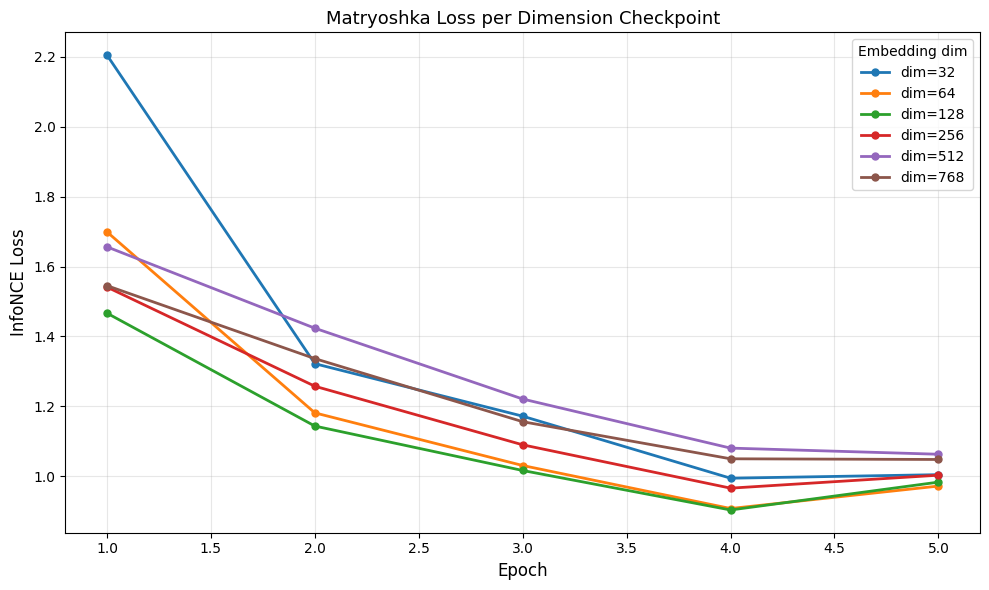


Key observation: Lower dimensions have higher loss (less capacity),
but the gap narrows during training as the model learns to pack
the most important information into the first dimensions.


In [69]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for d in mrl_loss_fn.dimensions:
    ax.plot(
        range(1, len(dim_losses_over_time[d]) + 1),
        dim_losses_over_time[d],
        "-o",
        label=f"dim={d}",
        linewidth=2,
        markersize=5,
    )

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("InfoNCE Loss", fontsize=12)
ax.set_title("Matryoshka Loss per Dimension Checkpoint", fontsize=13)
ax.legend(fontsize=10, title="Embedding dim")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey observation: Lower dimensions have higher loss (less capacity),")
print("but the gap narrows during training as the model learns to pack")
print("the most important information into the first dimensions.")

# 11) Summary & Key Takeaways

## Architecture Selection Guide

| Scenario | Recommendation | Why |
|---|---|---|
| Search over millions of docs | Bi-encoder + ANN index | Pre-compute once, search in ms |
| Re-rank top-50 results | Cross-encoder | Higher accuracy on small candidate set |
| Semantic similarity (STS) | Bi-encoder with mean pooling | Symmetric, efficient |
| Question answering | Bi-encoder retrieve → Cross-encoder re-rank | Best of both worlds |
| Resource-constrained deployment | Bi-encoder + Matryoshka | Adaptive dimensionality |

## Training Recipe Summary

1. **Start with a strong backbone** (e.g., BERT, RoBERTa, or a dedicated encoder like E5)
2. **Use mean pooling** — consistently better than [CLS] for sentence embeddings
3. **Train with InfoNCE / MNRL** and in-batch negatives
4. **Add hard negatives** — BM25 mined or from previous model checkpoint (ANCE)
5. **L2-normalize** outputs for cosine similarity compatibility
6. **Temperature τ ≈ 0.05** is a good starting point; can be learned
7. **Consider Matryoshka** if deployment requires flexible dimensionality